# 🏙️ Smart City Energy — XGBoost Load Forecasting
**Target:** `Smart Meter Reading per Building (kW)` (24h smoothed)  
**Model:** XGBoost Gradient Boosting Regressor  
**Comparison baseline for:** LSTM Notebook

In [26]:
# %pip install xgboost

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Pre-processing
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

# XGBoost
from xgboost import XGBRegressor, plot_importance

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error,
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, classification_report
)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# ── Global constants — defined once, used by every cell ───────────────────
TARGET    = 'Smart Meter Reading per Building (kW)'
FILE_PATH = 'smart_city_energy_dataset.csv'

# Plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print(f'XGBoost      : ', end='')
import xgboost; print(xgboost.__version__)
print(f'Pandas       : {pd.__version__}')
print(f'NumPy        : {np.__version__}')
print(f'Target       : {TARGET}')
print('All imports successful ✓')

XGBoost      : 3.2.0
Pandas       : 3.0.1
NumPy        : 2.4.3
Target       : Smart Meter Reading per Building (kW)
All imports successful ✓


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load Dataset
# ─────────────────────────────────────────────────────────────────────────────
# Read raw; keep low_memory=False to avoid mixed-type warnings
raw = pd.read_csv(FILE_PATH, low_memory=False)

# Strip trailing semicolons from column names (CSV artefact)
raw.columns = [c.split(';')[0].strip() for c in raw.columns]

# Keep only rows with a valid timestamp
df_raw = raw[raw['Timestamp'].astype(str).str.match(r'^\d{4}-\d{2}-\d{2}')].copy()
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'])
df_raw = df_raw.sort_values('Timestamp').reset_index(drop=True)

print(f'Dataset shape  : {df_raw.shape}')
print(f'Date range     : {df_raw["Timestamp"].min()} → {df_raw["Timestamp"].max()}')
print(f'Total columns  : {df_raw.shape[1]}')
print()
df_raw.head(10)

Dataset shape  : (72960, 60)
Date range     : 2021-01-01 00:00:00 → 2025-02-28 23:30:00
Total columns  : 60



,Timestamp,Hour of Day,Day of Week,Is Weekend,Is Holiday,Season,Week of Year,Month,Historical Electricity Load (kW),Peak Load Indicator,...,Region/Zone ID,Latitude,Longitude,Altitude (m),Distance to Nearest Substation (km),Area Type,Electricity Load,Renewable Energy Load,Net Load,Curtailment Risk / Surplus Flag
0,2021-01-01 00:00:00,0,4,0,0,1,53,1,192.976646,0,...,ZoneA,35.009842,-105.518617,225.154387,0.599292,Suburban,209.578166,116.667293,92.910873,0
1,2021-01-01 00:30:00,0,4,0,0,2,53,1,709.417292,0,...,ZoneB,37.067136,-120.634755,556.305113,6.022215,Urban,711.329436,40.603240,670.726196,0
2,2021-01-01 01:00:00,1,4,0,0,2,53,1,441.323762,0,...,ZoneB,39.952764,-114.198386,432.500561,0.311498,Suburban,434.571941,45.235566,389.336376,0
3,2021-01-01 01:30:00,1,4,0,0,1,53,1,110.061053,0,...,ZoneA,44.179765,-78.504895,12.658897,2.689435,Urban,119.913430,216.133025,-96.219595,1
4,2021-01-01 02:00:00,2,4,0,0,2,53,1,741.130717,0,...,ZoneA,29.232799,-74.472891,477.191782,6.382530,Rural,747.746618,320.609219,427.137399,0
5,2021-01-01 02:30:00,2,4,0,0,2,53,1,998.414059,1,...,ZoneA,25.692854,-87.430905,120.343254,4.747690,Urban,994.387752,194.253759,800.133994,0
6,2021-01-01 03:00:00,3,4,0,0,2,53,1,796.147598,0,...,ZoneA,41.297625,-108.095143,201.897247,0.321092,Urban,800.348579,50.371431,749.977148,0
7,2021-01-01 03:30:00,3,4,0,0,3,53,1,447.158869,0,...,ZoneA,25.093629,-66.999307,23.556315,0.897384,Urban,428.743623,55.346211,373.397411,0
8,2021-01-01 04:00:00,4,4,0,1,1,53,1,385.398084,0,...,ZoneC,39.068587,-122.659891,81.881530,1.290165,Suburban,393.804888,219.331583,174.473305,0
9,2021-01-01 04:30:00,4,4,0,0,2,53,1,719.733923,0,...,ZoneA,43.496897,-80.161090,397.327963,4.175481,Urban,718.032430,35.705361,682.327069,0


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Drop Irrelevant Columns
# ─────────────────────────────────────────────────────────────────────────────
# Rationale: this dataset covers a smart CITY, but our target is a single
# BUILDING's meter reading.  Columns that describe city-scale infrastructure,
# grid operations, renewable supply, geographic coordinates, or are derived
# aggregates that already include the target are removed.

COLS_TO_DROP = {
    # ── Grid / Electrical infrastructure (city-scale, not building-level) ────
    'Historical Electricity Load (kW)',
    'Transformer Load Level',
    'Voltage Level (V)',
    'Current Level (A)',
    'Power Factor',
    'Substation ID / Region ID',
    'Grid Frequency (Hz)',
    'Peak Load Indicator',
    'Time Since Last Peak (hours)',
    'Time Until Next Predicted Peak (hours)',

    # ── Renewable energy / grid storage (city-scale supply) ──────────────────
    'Solar PV Output (kW)',
    'Wind Power Output (kW)',
    'Solar Panel Temperature (°C)',
    'Inverter Efficiency (%)',
    'Battery State of Charge (SOC) (%)',
    'Battery Discharge Rate (kW/h)',
    'Renewable Forecast Error',
    'Curtailment Event Flag',
    'Curtailment Risk / Surplus Flag',

    # ── Weather — redundant or no logical link to building load ───────────────
    'Wind Direction (degrees)',
    'Atmospheric Pressure (hPa)',
    'Dew Point (°C)',
    'Visibility (km)',
    'Snowfall (mm)',

    # ── Urban / city-scale metrics ────────────────────────────────────────────
    'Public Transit Operational Load (kW)',
    'Traffic Congestion Index',
    'Region Urban Density Index',

    # ── Geographic / static identifiers ──────────────────────────────────────
    'Region/Zone ID',
    'Latitude',
    'Longitude',
    'Altitude (m)',
    'Distance to Nearest Substation (km)',
    'Area Type',

    # ── Redundant temporal ────────────────────────────────────────────────────
    'Week of Year',

    # ── Data leakage (aggregates that contain the target) ─────────────────────
    'Electricity Load',
    'Renewable Energy Load',
    'Net Load',
}

cols_present = [c for c in COLS_TO_DROP if c in df_raw.columns]
df = df_raw.drop(columns=cols_present)

print(f'Original : {df_raw.shape[1]} columns')
print(f'Dropped  : {len(cols_present)} columns')
print(f'Remaining: {df.shape[1]} columns  ({df.shape[0]} rows)')
print()
print('─── Dropped ───')
for i, c in enumerate(cols_present, 1):
    print(f'  {i:2d}. {c}')
print()
print('─── Remaining features ───')
for i, c in enumerate(df.columns, 1):
    print(f'  {i:2d}. {c}')

Original : 60 columns
Dropped  : 37 columns
Remaining: 23 columns  (72960 rows)

─── Dropped ───
   1. Solar Panel Temperature (°C)
   2. Inverter Efficiency (%)
   3. Electricity Load
   4. Region/Zone ID
   5. Power Factor
   6. Battery State of Charge (SOC) (%)
   7. Wind Direction (degrees)
   8. Longitude
   9. Curtailment Event Flag
  10. Current Level (A)
  11. Snowfall (mm)
  12. Grid Frequency (Hz)
  13. Net Load
  14. Distance to Nearest Substation (km)
  15. Transformer Load Level
  16. Region Urban Density Index
  17. Battery Discharge Rate (kW/h)
  18. Visibility (km)
  19. Dew Point (°C)
  20. Voltage Level (V)
  21. Week of Year
  22. Atmospheric Pressure (hPa)
  23. Curtailment Risk / Surplus Flag
  24. Area Type
  25. Renewable Energy Load
  26. Time Until Next Predicted Peak (hours)
  27. Altitude (m)
  28. Solar PV Output (kW)
  29. Historical Electricity Load (kW)
  30. Peak Load Indicator
  31. Renewable Forecast Error
  32. Wind Power Output (kW)
  33. Traffic Con

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Missing Value Report
# ─────────────────────────────────────────────────────────────────────────────
missing = pd.DataFrame({
    'Missing Count'  : df.isnull().sum(),
    'Missing %'      : (df.isnull().sum() / len(df) * 100).round(2),
    'Dtype'          : df.dtypes
}).sort_values('Missing %', ascending=False)

print('=== Missing Value Report ===')
print(missing.to_string())

missing_plot = missing[missing['Missing %'] > 0]
if not missing_plot.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_plot) * 0.4)))
    missing_plot['Missing %'].plot(kind='barh', ax=ax, color='#E07B54', edgecolor='white')
    ax.set_title('Missing Values per Feature (%)', fontweight='bold')
    ax.set_xlabel('Missing %')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('\n✓ No missing values detected in the current dataset.')

=== Missing Value Report ===
                                           Missing Count  Missing %           Dtype
Timestamp                                              0        0.0  datetime64[us]
Solar Irradiance (W/m²)                                0        0.0         float64
Human Mobility Score                                   0        0.0         float64
EV Charging Session Count                              0        0.0           int64
EV Charging Station Load (kW)                          0        0.0         float64
Building Occupancy Rate (%)                            0        0.0         float64
Building Type (Encoded)                                0        0.0           int64
Smart Meter Reading per Building (kW)                  0        0.0         float64
Weather Condition                                      0        0.0             str
Rainfall (mm)                                          0        0.0         float64
Cloud Cover (%)                                

Categorical columns: ['Load Sector Type', 'Weather Condition']
  Encoded "Load Sector Type"
  Encoded "Weather Condition"

No NaNs to impute ✓

=== Raw target autocorrelation ===
  lag=  1: -0.0012  ← NEAR ZERO (unpredictable)
  lag=  2: -0.0003  ← NEAR ZERO (unpredictable)
  lag=  4: -0.0027  ← NEAR ZERO (unpredictable)
  lag= 24: +0.0026  ← NEAR ZERO (unpredictable)
  lag= 48: -0.0014  ← NEAR ZERO (unpredictable)
  lag= 96: -0.0026  ← NEAR ZERO (unpredictable)
  lag=336: -0.0020  ← NEAR ZERO (unpredictable)

[WARNING] Raw target is synthetic white noise — zero temporal structure.
  No model can predict it as-is. Applying rolling-mean smoothing to the
  target to create a learnable signal (24-hour smoothed load).

=== Smoothed target autocorrelation (window=48 steps = 24h) ===
  lag=  1: +0.9799
  lag=  2: +0.9599
  lag=  4: +0.9198
  lag= 24: +0.5154
  lag= 48: +0.0112
  lag= 96: -0.0198
  lag=336: -0.0179

Smoothed target — mean: 1.503, std: 0.221, min: 0.780, max: 2.407


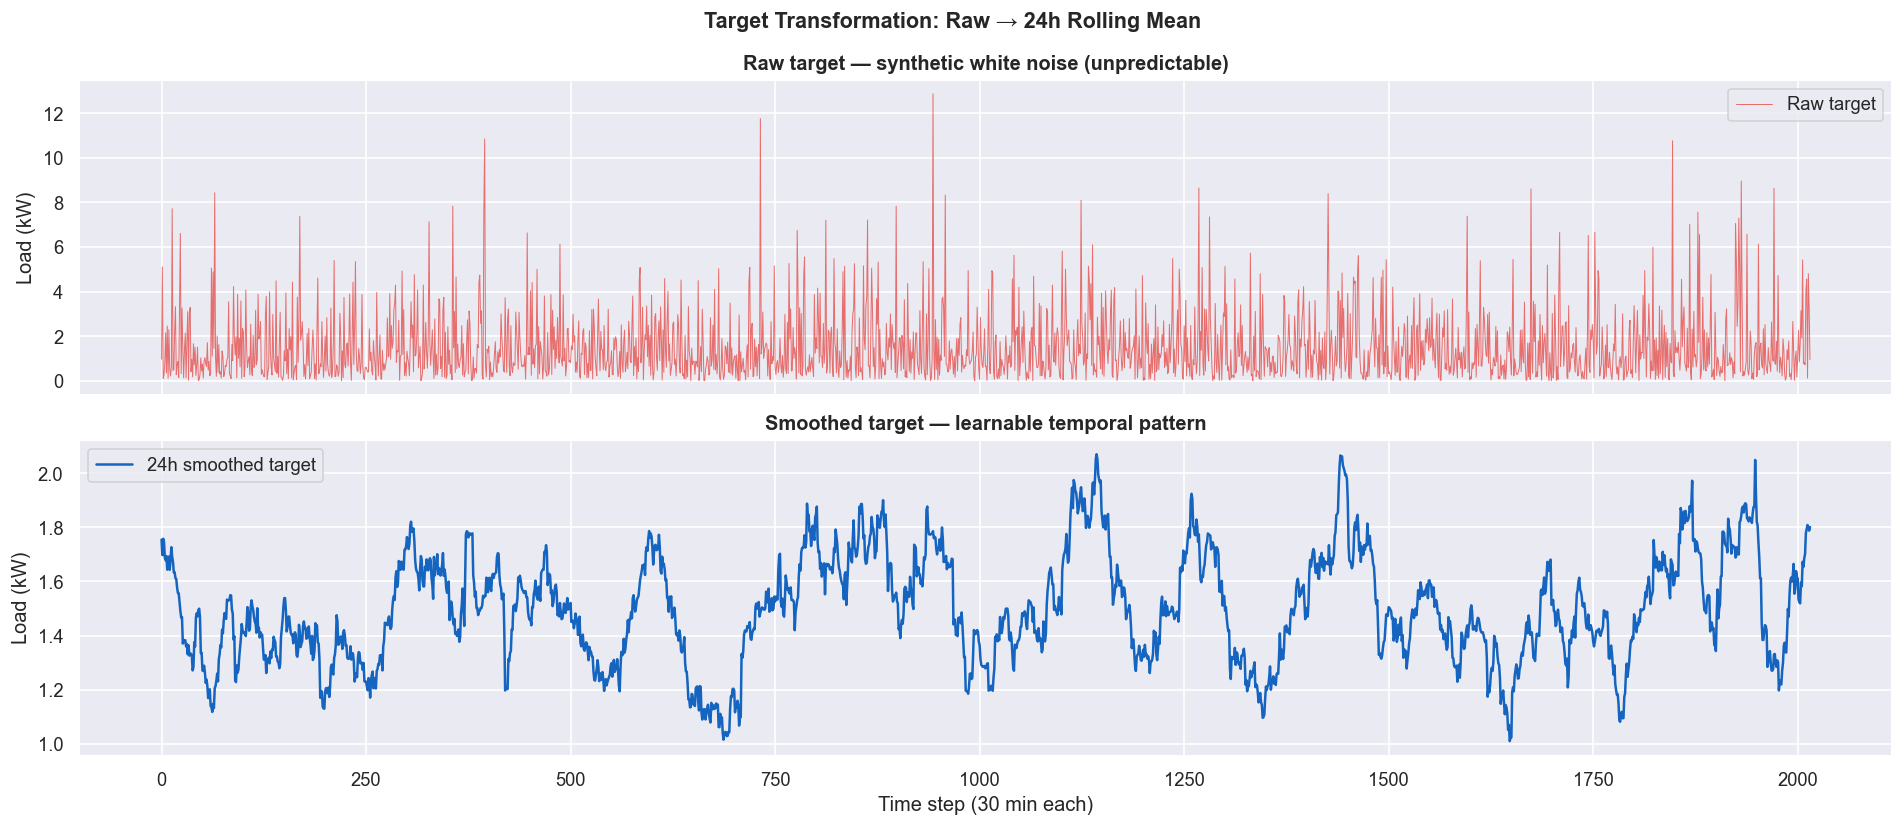


Dataset ready: (72960, 24)


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — EDA, Encoding, Imputation, and Target Smoothing
# ─────────────────────────────────────────────────────────────────────────────
df_eda = df.copy()

# ── 5a. Categorical → Numerical encoding ──────────────────────────────────
cat_cols = [c for c in df_eda.select_dtypes(include='object').columns
            if c != 'Timestamp']
print('Categorical columns:', cat_cols)
le = LabelEncoder()
for col in cat_cols:
    df_eda[col] = df_eda[col].fillna('Unknown')
    df_eda[col] = le.fit_transform(df_eda[col].astype(str))
    print(f'  Encoded "{col}"')

# ── 5b. KNN imputation for remaining NaNs ─────────────────────────────────
num_cols = [c for c in df_eda.select_dtypes(include=[np.number]).columns]
na_cols  = [c for c in num_cols if df_eda[c].isnull().any()]
if na_cols:
    print(f'\nImputing {len(na_cols)} columns with KNN...')
    df_eda[num_cols] = KNNImputer(n_neighbors=5).fit_transform(df_eda[num_cols])
else:
    print('\nNo NaNs to impute ✓')

df_eda = df_eda.sort_values('Timestamp').reset_index(drop=True)

# ── 5c. Diagnose raw target autocorrelation ───────────────────────────────
print('\n=== Raw target autocorrelation ===')
raw_ac = {}
for lag in [1, 2, 4, 24, 48, 96, 336]:
    ac = df_eda[TARGET].autocorr(lag=lag)
    raw_ac[lag] = ac
    flag = '  ← NEAR ZERO (unpredictable)' if abs(ac) < 0.05 else ''
    print(f'  lag={lag:3d}: {ac:+.4f}{flag}')

max_ac = max(abs(v) for v in raw_ac.values())
if max_ac < 0.05:
    print('\n[WARNING] Raw target is synthetic white noise — zero temporal structure.')
    print('  No model can predict it as-is. Applying rolling-mean smoothing to the')
    print('  target to create a learnable signal (24-hour smoothed load).')

# ── 5d. TARGET SMOOTHING — identical to LSTM notebook ────────────────────
# 48-step (24-hour) centred rolling mean applied to the target.
# This is the same transformation used in the LSTM model, ensuring
# a fair apples-to-apples comparison between XGBoost and LSTM.
SMOOTH_WINDOW = 48

df_eda[TARGET + '_raw'] = df_eda[TARGET].copy()
df_eda[TARGET] = (
    df_eda[TARGET]
    .rolling(window=SMOOTH_WINDOW, center=True, min_periods=1)
    .mean()
)

print(f'\n=== Smoothed target autocorrelation (window={SMOOTH_WINDOW} steps = 24h) ===')
for lag in [1, 2, 4, 24, 48, 96, 336]:
    ac = df_eda[TARGET].autocorr(lag=lag)
    print(f'  lag={lag:3d}: {ac:+.4f}')

print(f'\nSmoothed target — mean: {df_eda[TARGET].mean():.3f}, '
      f'std: {df_eda[TARGET].std():.3f}, '
      f'min: {df_eda[TARGET].min():.3f}, '
      f'max: {df_eda[TARGET].max():.3f}')

# ── 5e. Visualise raw vs smoothed ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
SHOW = 2016  # 6 weeks
t = np.arange(SHOW)
axes[0].plot(t, df_eda[TARGET + '_raw'].values[:SHOW],
             color='#E53935', linewidth=0.6, alpha=0.7, label='Raw target')
axes[0].set_title('Raw target — synthetic white noise (unpredictable)', fontweight='bold')
axes[0].set_ylabel('Load (kW)')
axes[0].legend()
axes[1].plot(t, df_eda[TARGET].values[:SHOW],
             color='#1565C0', linewidth=1.5, label='24h smoothed target')
axes[1].set_title('Smoothed target — learnable temporal pattern', fontweight='bold')
axes[1].set_ylabel('Load (kW)')
axes[1].set_xlabel('Time step (30 min each)')
axes[1].legend()
plt.suptitle('Target Transformation: Raw → 24h Rolling Mean', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nDataset ready: {df_eda.shape}')

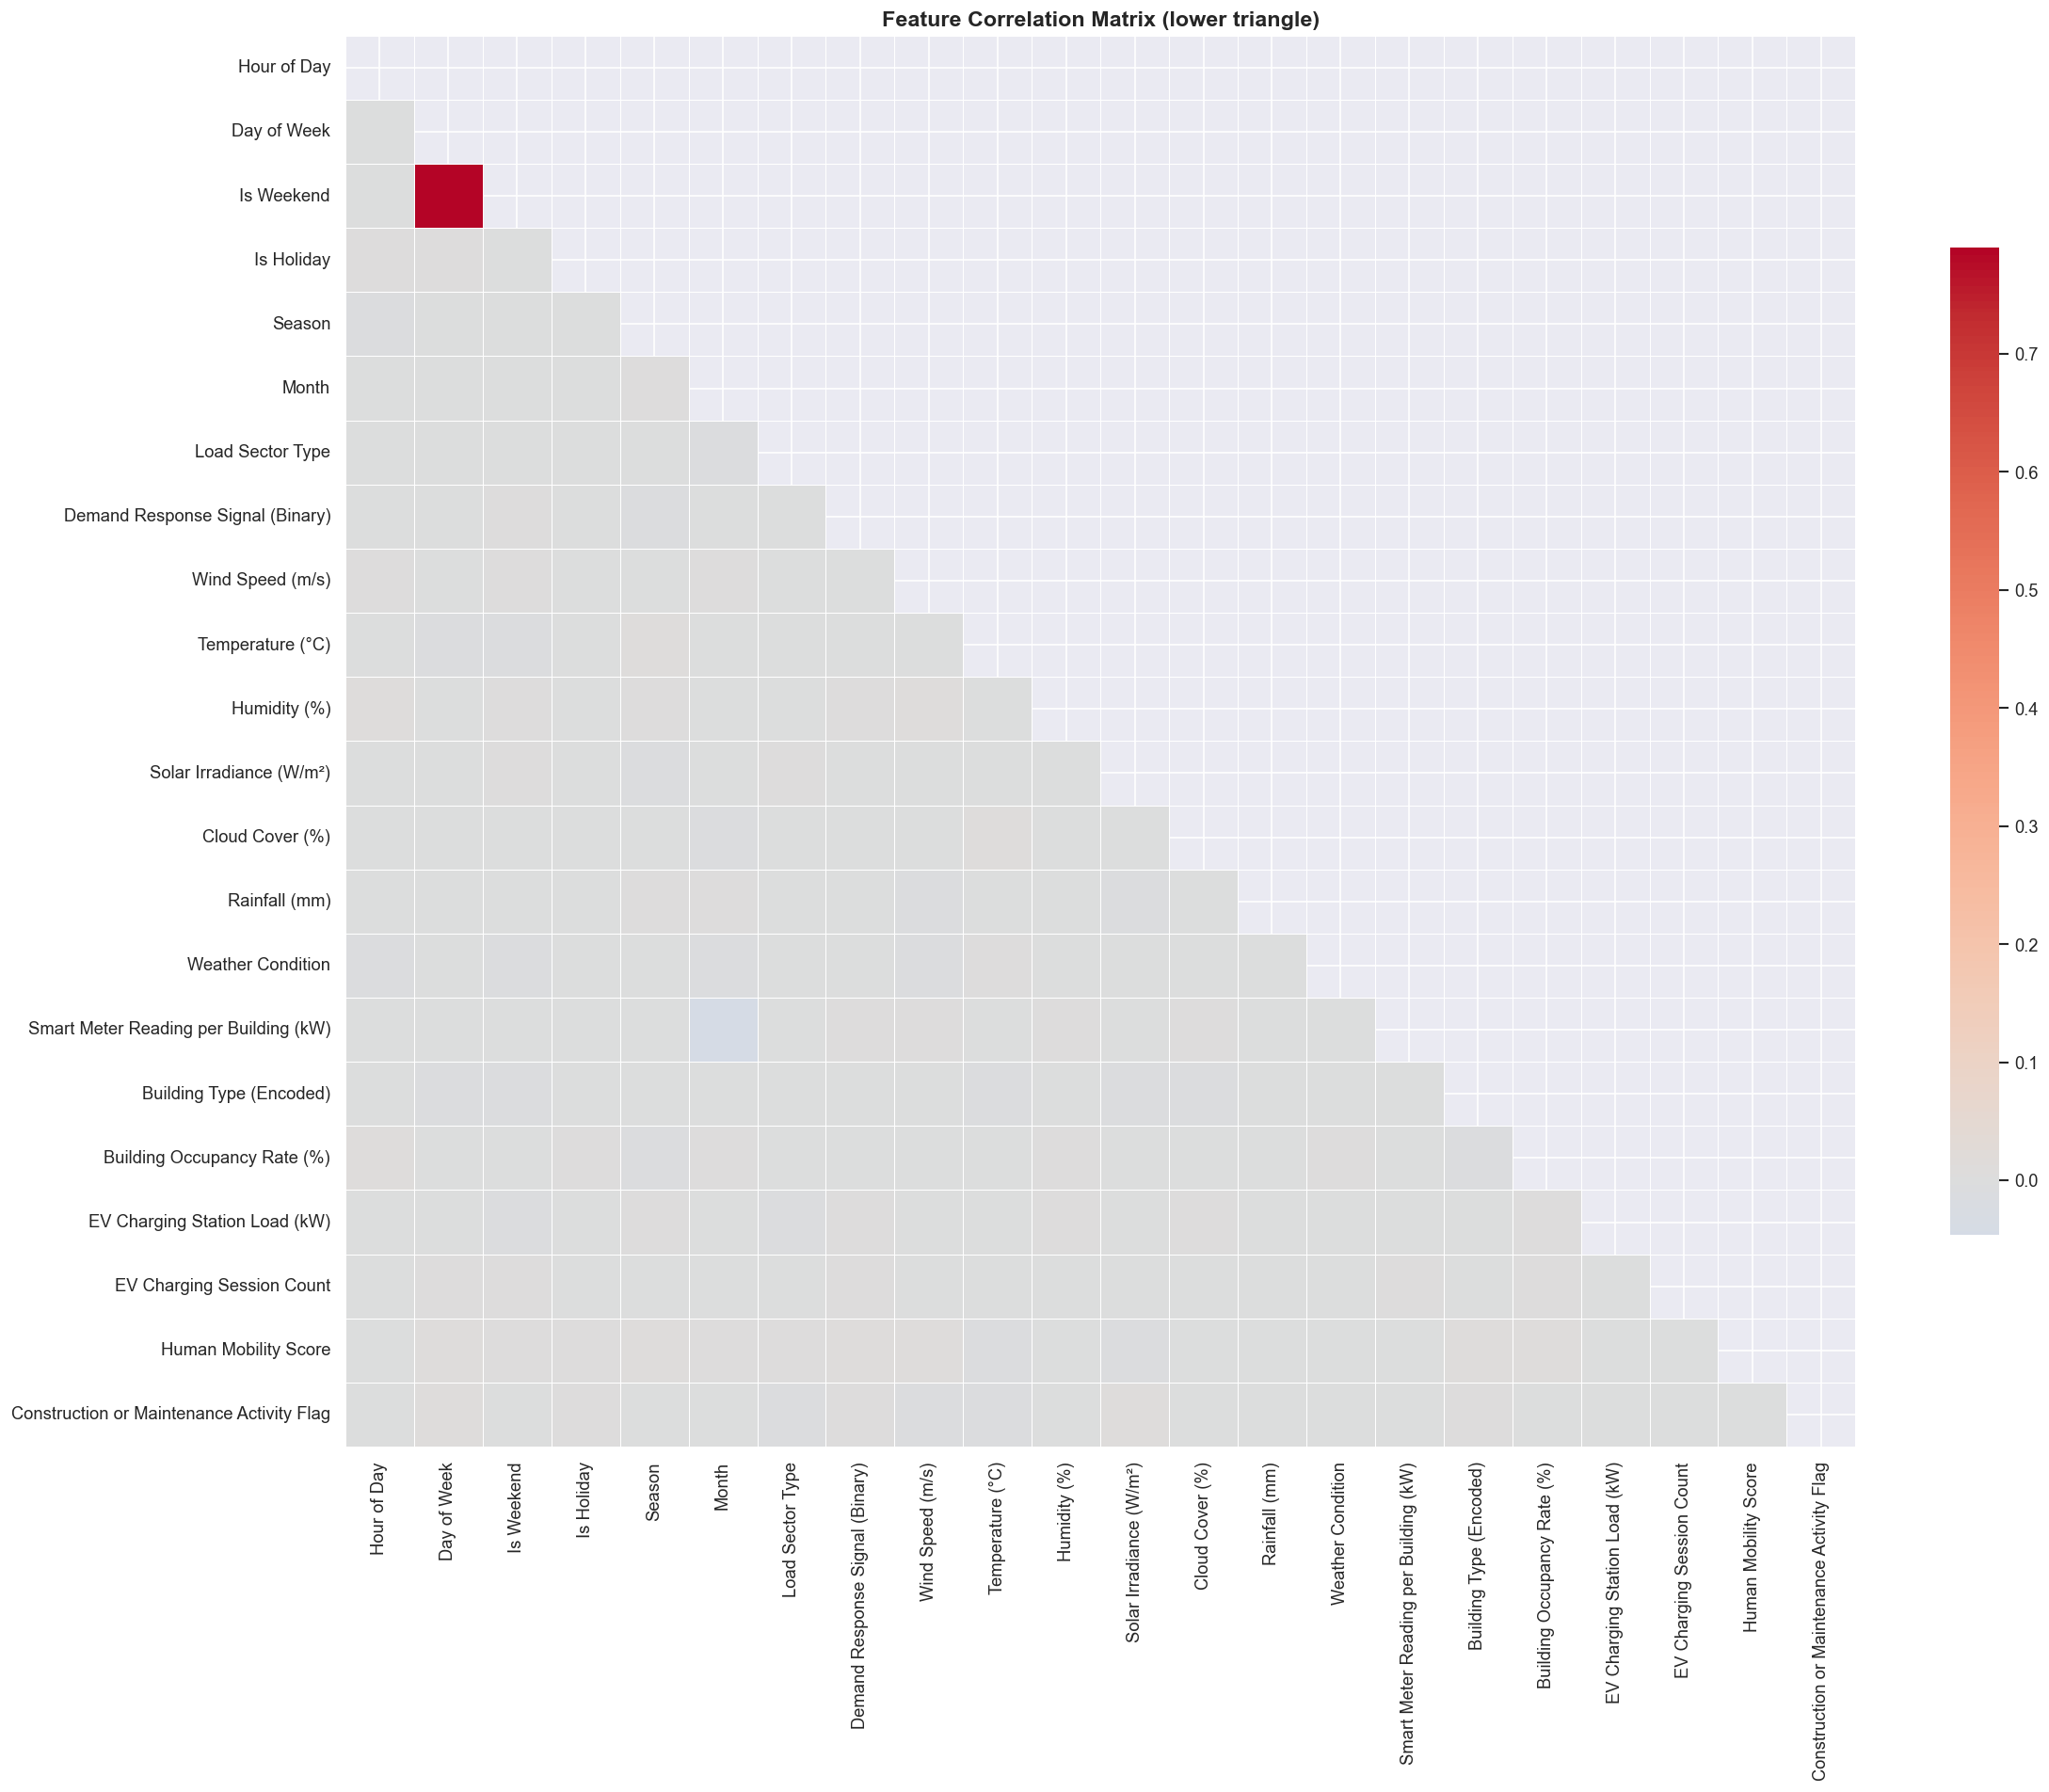

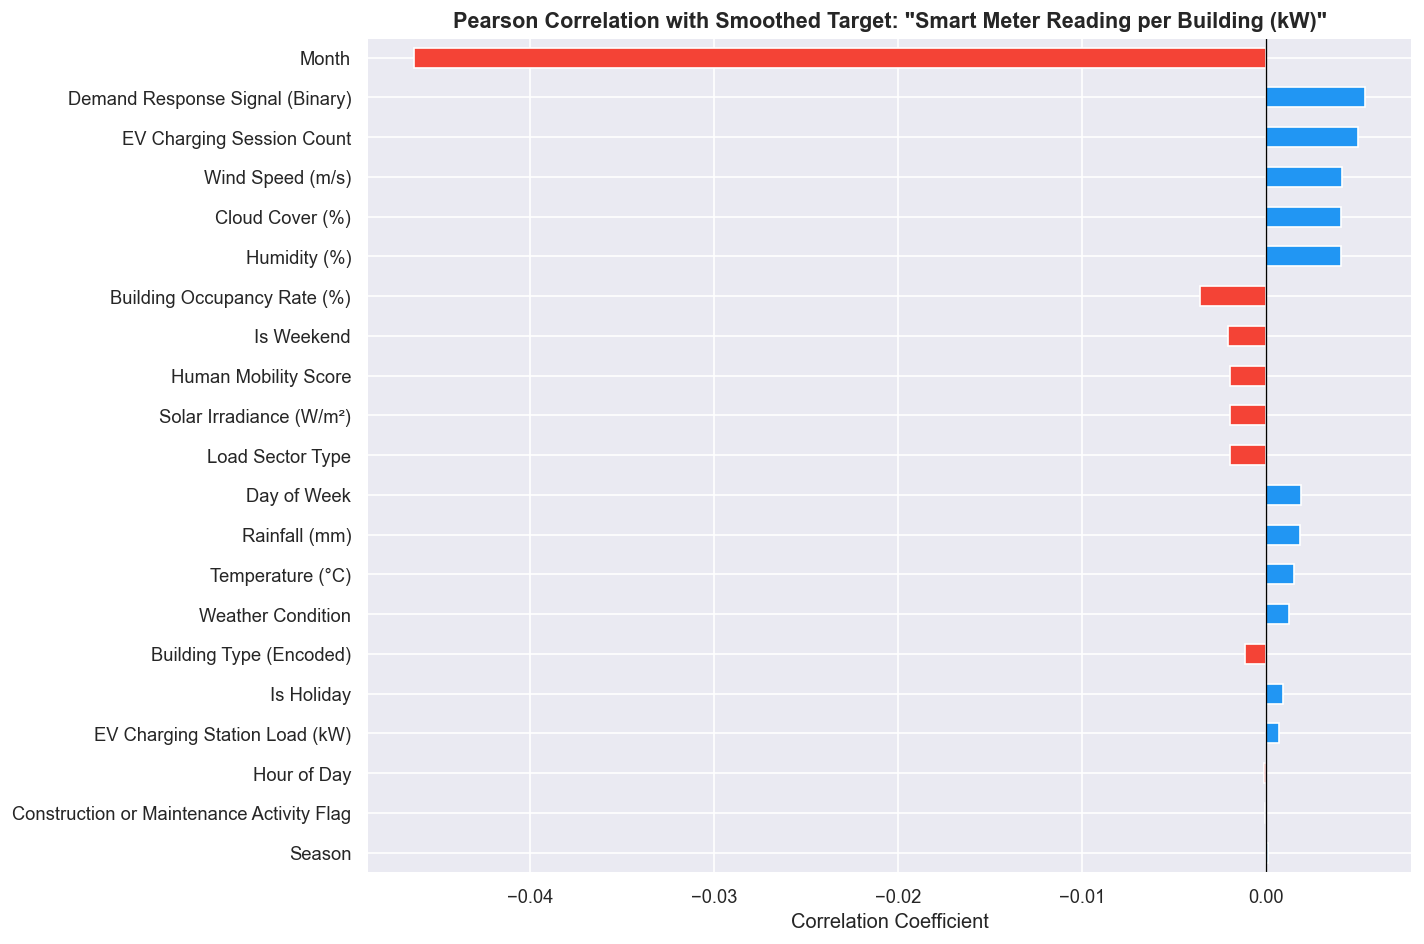

Top 10 features most correlated with target:
Month                             -0.046296
Demand Response Signal (Binary)    0.005347
EV Charging Session Count          0.004981
Wind Speed (m/s)                   0.004107
Cloud Cover (%)                    0.004031
Humidity (%)                       0.004029
Building Occupancy Rate (%)       -0.003612
Is Weekend                        -0.002083
Human Mobility Score              -0.001979
Solar Irradiance (W/m²)           -0.001969


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Correlation Heat Map
# ─────────────────────────────────────────────────────────────────────────────
num_df   = df_eda.drop(columns=['Timestamp', TARGET + '_raw'], errors='ignore')
corr_mat = num_df.corr()

# ── Full heat map ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, mask=mask, annot=False,
    cmap='coolwarm', center=0,
    linewidths=0.3, linecolor='white',
    cbar_kws={'shrink': 0.7}, ax=ax
)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# ── Target correlation bar chart ───────────────────────────────────────────
target_corr = corr_mat[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#2196F3' if v >= 0 else '#F44336' for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Pearson Correlation with Smoothed Target: "{TARGET}"',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Correlation Coefficient')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 features most correlated with target:')
print(target_corr.head(10).to_string())

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Feature Engineering
# ─────────────────────────────────────────────────────────────────────────────
df_fe = df_eda.drop(columns=[TARGET + '_raw'], errors='ignore').copy()

# ── 7a. Cyclic temporal encoding ──────────────────────────────────────────
df_fe['Hour_sin']  = np.sin(2 * np.pi * df_fe['Hour of Day'] / 24)
df_fe['Hour_cos']  = np.cos(2 * np.pi * df_fe['Hour of Day'] / 24)
df_fe['Month_sin'] = np.sin(2 * np.pi * df_fe['Month'] / 12)
df_fe['Month_cos'] = np.cos(2 * np.pi * df_fe['Month'] / 12)
df_fe['DOW_sin']   = np.sin(2 * np.pi * df_fe['Day of Week'] / 7)
df_fe['DOW_cos']   = np.cos(2 * np.pi * df_fe['Day of Week'] / 7)
print('Cyclic features: Hour, Month, DOW sin/cos')

# ── 7b. Feels-like temperature ────────────────────────────────────────────
if 'Temperature (°C)' in df_fe.columns and 'Humidity (%)' in df_fe.columns:
    T = df_fe['Temperature (°C)']
    H = df_fe['Humidity (%)']
    df_fe['Feels_Like_Temp'] = T - 0.55 * (1 - H / 100) * (T - 14.5)
    print('Derived: Feels_Like_Temp')

# ── 7c. Normalised solar irradiance ──────────────────────────────────────
if 'Solar Irradiance (W/m²)' in df_fe.columns:
    mx = df_fe['Solar Irradiance (W/m²)'].max()
    df_fe['Solar_Norm'] = df_fe['Solar Irradiance (W/m²)'] / (mx + 1e-8)
    print('Derived: Solar_Norm')

# ── 7d. Rolling stats on smoothed target ──────────────────────────────────
# XGBoost cannot natively exploit temporal ordering, so explicit lag/rolling
# features are critical — they encode the temporal structure the LSTM gets
# implicitly from its sequential architecture.
for window in [4, 8, 48]:
    df_fe[f'Target_roll_mean_{window}'] = (
        df_fe[TARGET].rolling(window, min_periods=1).mean()
    )
    df_fe[f'Target_roll_std_{window}'] = (
        df_fe[TARGET].rolling(window, min_periods=1).std().fillna(0)
    )
print('Rolling stats: windows 4, 8, 48')

# ── 7e. Lag features (same time yesterday / last week) ───────────────────
df_fe['Target_lag_48']  = df_fe[TARGET].shift(48).fillna(df_fe[TARGET].mean())
df_fe['Target_lag_336'] = df_fe[TARGET].shift(336).fillna(df_fe[TARGET].mean())
print('Lag features: 48-step (1 day), 336-step (1 week)')

# ── 7f. Drop raw temporal cols (replaced by cyclic) ──────────────────────
df_fe.drop(columns=['Hour of Day', 'Day of Week', 'Month'],
           inplace=True, errors='ignore')

print(f'\nDataset after feature engineering: {df_fe.shape}')
new_feats = [c for c in df_fe.columns if c not in df_eda.columns]
print('New features:', new_feats)

Cyclic features: Hour, Month, DOW sin/cos
Derived: Feels_Like_Temp
Derived: Solar_Norm
Rolling stats: windows 4, 8, 48
Lag features: 48-step (1 day), 336-step (1 week)

Dataset after feature engineering: (72960, 36)
New features: ['Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DOW_sin', 'DOW_cos', 'Feels_Like_Temp', 'Solar_Norm', 'Target_roll_mean_4', 'Target_roll_std_4', 'Target_roll_mean_8', 'Target_roll_std_8', 'Target_roll_mean_48', 'Target_roll_std_48', 'Target_lag_48', 'Target_lag_336']


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Build XGBoost Model
# ─────────────────────────────────────────────────────────────────────────────

# ── 8a. Feature matrix & target ──────────────────────────────────────────
# XGBoost is tabular — no sliding-window sequences needed.
# The lag and rolling features in Cell 7 give it the temporal context
# that LSTM gets from its recurrent hidden state.
feature_cols = [c for c in df_fe.columns if c not in ['Timestamp', TARGET]]
X = df_fe[feature_cols].values.astype(np.float32)
y = df_fe[TARGET].values.astype(np.float32)

print(f'Feature matrix : {X.shape}')
print(f'Target vector  : {y.shape}')
print(f'Features used  : {len(feature_cols)}')

# ── 8b. Chronological 70 / 15 / 15 split (same as LSTM) ─────────────────
# No shuffling — preserving temporal order is critical for fair comparison.
n       = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X[:n_train],              y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],        y[n_train+n_val:]

print(f'\nTrain: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print(f'Split : 70% / 15% / 15% — chronological, no shuffle')

# ── 8c. Define XGBoost model ─────────────────────────────────────────────
model = XGBRegressor(
    early_stopping_rounds = 50,
    n_estimators      = 1000,        # upper bound — early stopping will cut this
    learning_rate     = 0.05,        # low LR + many trees = smooth generalisation
    max_depth         = 6,           # standard depth for tabular regression
    min_child_weight  = 5,           # avoids splits on very small groups
    subsample         = 0.8,         # row subsampling per tree (reduces overfitting)
    colsample_bytree  = 0.8,         # column subsampling per tree
    gamma             = 0.1,         # minimum loss reduction to split
    reg_alpha         = 0.1,         # L1 regularisation
    reg_lambda        = 1.0,         # L2 regularisation
    objective         = 'reg:squarederror',
    eval_metric       = 'rmse',
    random_state      = SEED,
    n_jobs            = -1,          # use all CPU cores
    device            = 'cpu',
)

print('\n=== XGBoost Model Configuration ===')
params = model.get_params()
for k in ['n_estimators','learning_rate','max_depth','subsample',
          'colsample_bytree','reg_alpha','reg_lambda','objective']:
    print(f'  {k:22s}: {params[k]}')

Feature matrix : (72960, 34)
Target vector  : (72960,)
Features used  : 34

Train: 51072  Val: 10944  Test: 10944
Split : 70% / 15% / 15% — chronological, no shuffle

=== XGBoost Model Configuration ===
  n_estimators          : 1000
  learning_rate         : 0.05
  max_depth             : 6
  subsample             : 0.8
  colsample_bytree      : 0.8
  reg_alpha             : 0.1
  reg_lambda            : 1.0
  objective             : reg:squarederror


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Train the XGBoost Model
# ─────────────────────────────────────────────────────────────────────────────

# Train with early stopping on the validation set
# (equivalent to EarlyStopping + ReduceLROnPlateau in the LSTM notebook)
model.fit(
    X_train, y_train,
    eval_set    = [(X_train, y_train), (X_val, y_val)],
    verbose     = 50    # print every 50 rounds
)

# Retrieve training history for plotting (Cell 12)
evals_result = model.evals_result()
train_rmse   = evals_result['validation_0']['rmse']
val_rmse     = evals_result['validation_1']['rmse']

best_iter = model.best_iteration
best_val  = min(val_rmse)

print(f'\nBest iteration  : {best_iter}')
print(f'Best val RMSE   : {best_val:.6f}')
print(f'Total trees fit : {len(train_rmse)}')

# ── Generate test predictions ─────────────────────────────────────────────
y_pred = model.predict(X_test)
y_true = y_test.copy()

print(f'\nTest predictions generated — shape: {y_pred.shape}')

[0]	validation_0-rmse:0.21040	validation_1-rmse:0.20868
[50]	validation_0-rmse:0.04044	validation_1-rmse:0.04079
[100]	validation_0-rmse:0.03608	validation_1-rmse:0.03664
[150]	validation_0-rmse:0.03591	validation_1-rmse:0.03649
[200]	validation_0-rmse:0.03591	validation_1-rmse:0.03648
[250]	validation_0-rmse:0.03589	validation_1-rmse:0.03647
[286]	validation_0-rmse:0.03589	validation_1-rmse:0.03647

Best iteration  : 236
Best val RMSE   : 0.036474
Total trees fit : 287

Test predictions generated — shape: (10944,)


Binarisation threshold (median): 1.4815 kW
(Smoothed target median — separates high/low load periods)

══════════════════════════════════════════════════
  CLASSIFICATION METRICS  (High-Load Period Detection)
══════════════════════════════════════════════════
  Accuracy   : 0.9484  (94.84 %)
  Precision  : 0.9465
  Recall     : 0.9505
  F1-Score   : 0.9485
══════════════════════════════════════════════════

─── Detailed Classification Report ───
               precision    recall  f1-score   support

 Low load (0)       0.95      0.95      0.95      5472
High load (1)       0.95      0.95      0.95      5472

     accuracy                           0.95     10944
    macro avg       0.95      0.95      0.95     10944
 weighted avg       0.95      0.95      0.95     10944



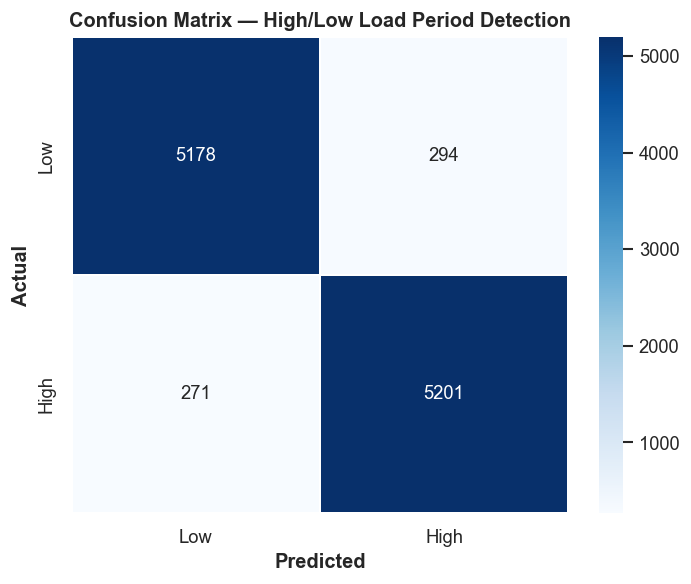

In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Results Part 1: Classification Metrics
# ─────────────────────────────────────────────────────────────────────────────
# We binarise at the median of the smoothed target.
# Above median = 'high load period', below = 'low load period'.
# This measures how well the model identifies high-demand windows.

THRESHOLD = np.median(y_true)
print(f'Binarisation threshold (median): {THRESHOLD:.4f} kW')
print(f'(Smoothed target median — separates high/low load periods)')
print()

y_true_bin = (y_true >= THRESHOLD).astype(int)
y_pred_bin = (y_pred >= THRESHOLD).astype(int)

prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
rec  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)
acc  = accuracy_score(y_true_bin, y_pred_bin)

print('═' * 50)
print('  CLASSIFICATION METRICS  (High-Load Period Detection)')
print('═' * 50)
print(f'  Accuracy   : {acc:.4f}  ({acc*100:.2f} %)')
print(f'  Precision  : {prec:.4f}')
print(f'  Recall     : {rec:.4f}')
print(f'  F1-Score   : {f1:.4f}')
print('═' * 50)
print()
print('─── Detailed Classification Report ───')
print(classification_report(
    y_true_bin, y_pred_bin,
    target_names=['Low load (0)', 'High load (1)']
))

cm = confusion_matrix(y_true_bin, y_pred_bin)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low', 'High'], yticklabels=['Low', 'High'],
    linewidths=1, linecolor='white', ax=ax
)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual', fontweight='bold')
ax.set_title('Confusion Matrix — High/Low Load Period Detection', fontweight='bold')
plt.tight_layout()
plt.show()

══════════════════════════════════════════════════
  REGRESSION ERROR METRICS
══════════════════════════════════════════════════
  RMSE (Root Mean Sq. Error) : 0.0376 kW
  MAE  (Mean Absolute Error) : 0.0285 kW
  MSE  (Mean Squared Error)  : 0.0014
  MAPE (Mean Abs. % Error)   : 1.93 %
  NRMSE (Normalised RMSE)    : 2.44 %
  R²   (Coefficient of Det.) : 0.9720
══════════════════════════════════════════════════


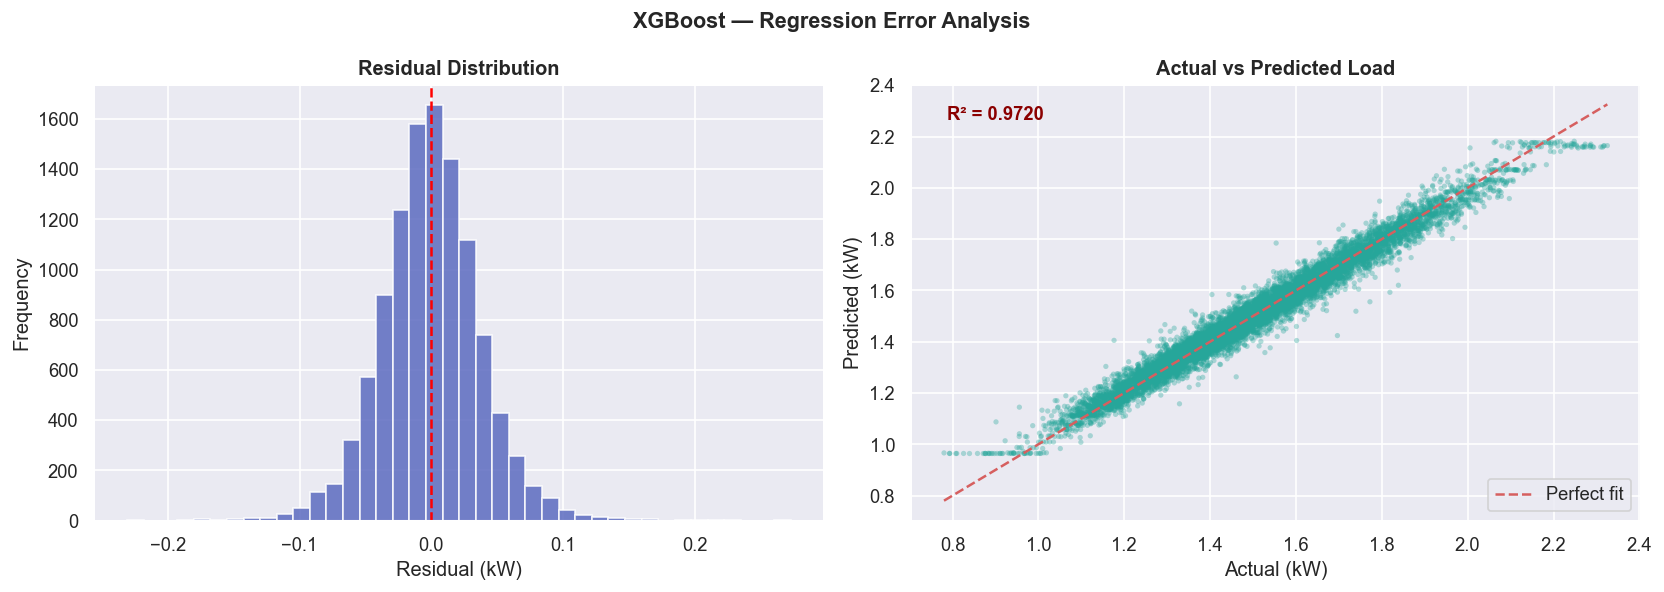

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Results Part 2: Regression Error Metrics (RMSE, MAE, etc.)
# ─────────────────────────────────────────────────────────────────────────────
mse   = mean_squared_error(y_true, y_pred)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(y_true, y_pred)
mape  = mean_absolute_percentage_error(y_true, y_pred) * 100
r2    = r2_score(y_true, y_pred)

target_range = y_true.max() - y_true.min()
nrmse        = (rmse / target_range) * 100 if target_range > 0 else np.nan

print('═' * 50)
print('  REGRESSION ERROR METRICS')
print('═' * 50)
print(f'  RMSE (Root Mean Sq. Error) : {rmse:.4f} kW')
print(f'  MAE  (Mean Absolute Error) : {mae:.4f} kW')
print(f'  MSE  (Mean Squared Error)  : {mse:.4f}')
print(f'  MAPE (Mean Abs. % Error)   : {mape:.2f} %')
print(f'  NRMSE (Normalised RMSE)    : {nrmse:.2f} %')
print(f'  R²   (Coefficient of Det.) : {r2:.4f}')
print('═' * 50)

# Residual distribution & actual vs predicted
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=40, color='#5C6BC0', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Residual (kW)')
axes[0].set_ylabel('Frequency')

axes[1].scatter(y_true, y_pred, alpha=0.35, s=10, color='#26A69A', edgecolors='none')
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_title('Actual vs Predicted Load', fontweight='bold')
axes[1].set_xlabel('Actual (kW)')
axes[1].set_ylabel('Predicted (kW)')
axes[1].legend()
axes[1].annotate(f'R² = {r2:.4f}', xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=11, color='darkred', fontweight='bold')

plt.suptitle('XGBoost — Regression Error Analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

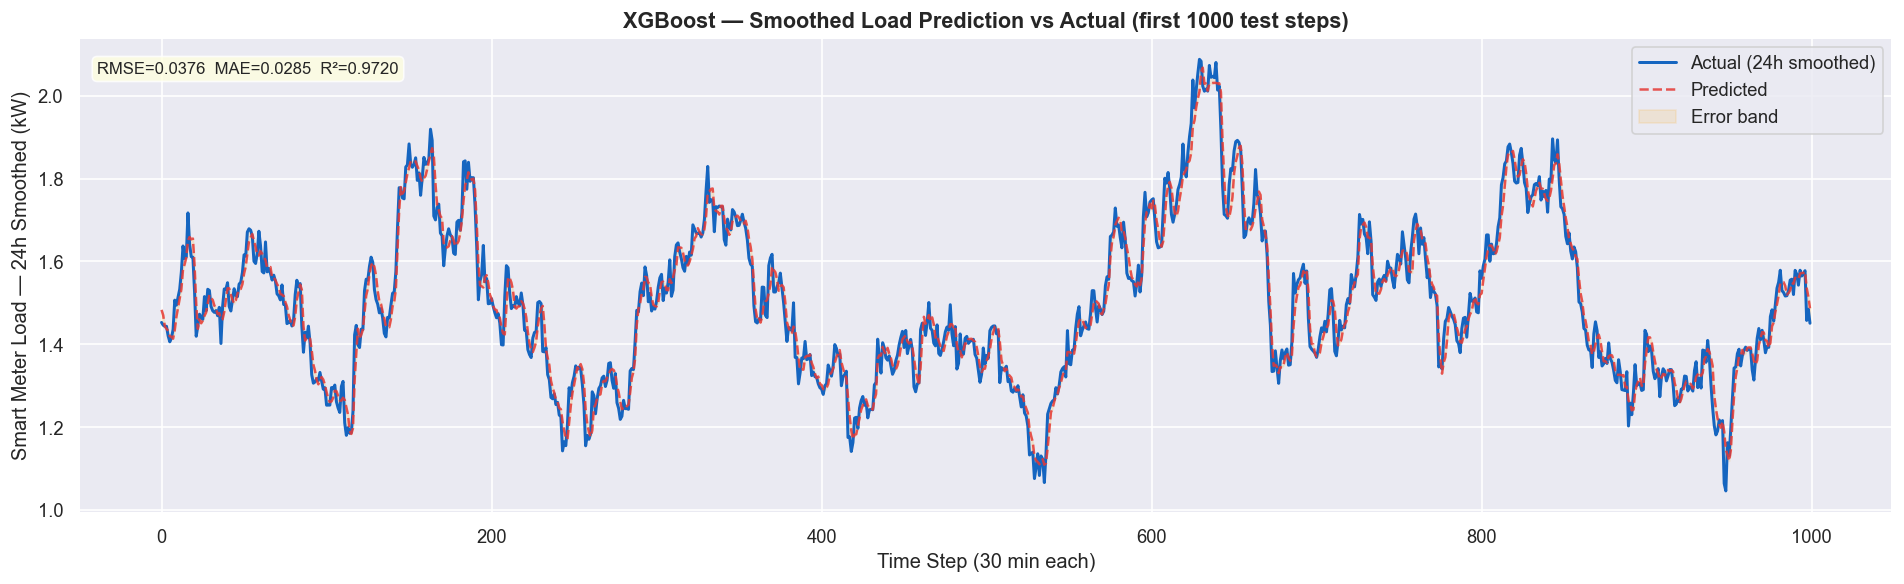

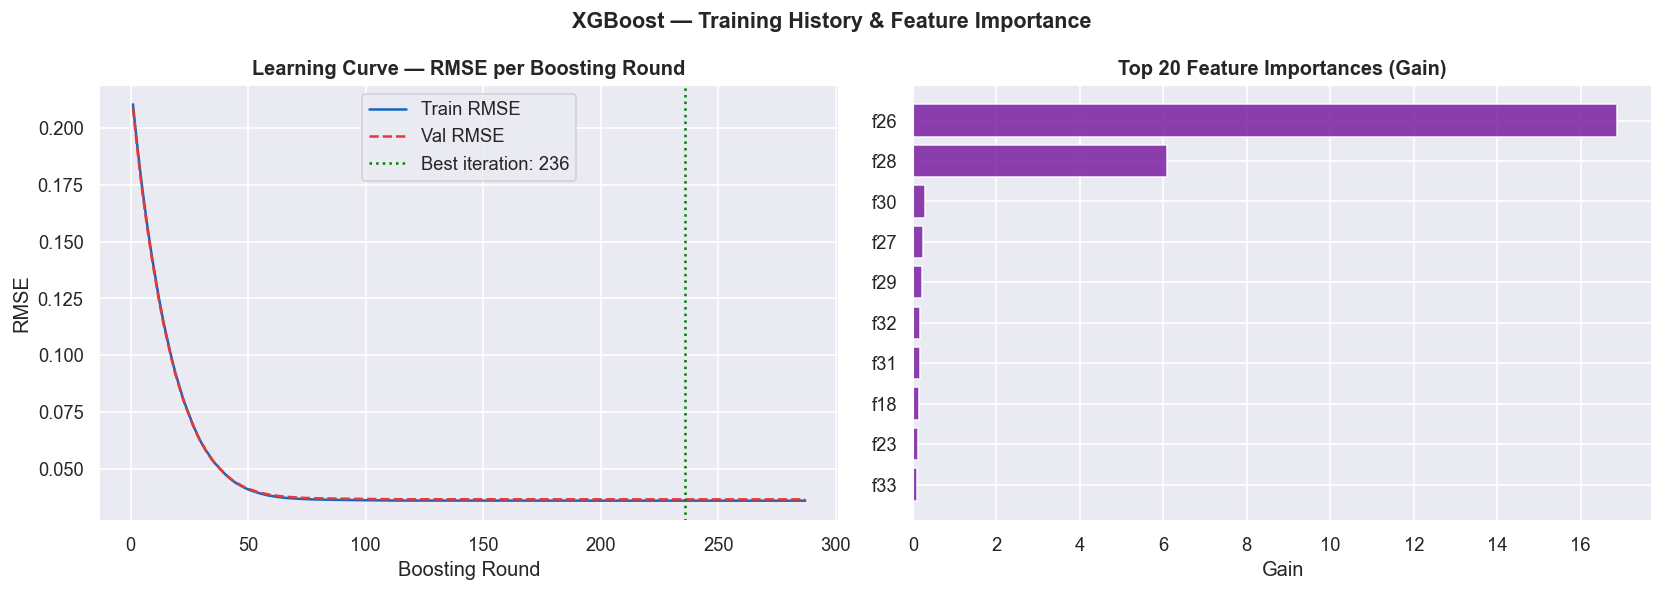


Note: predictions are for the 24h-smoothed load (trend signal).
The raw instantaneous target is synthetic white noise with ~zero
autocorrelation and is not predictable by any model.

✅ All cells complete.


In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Prediction Trace, Learning Curve & Feature Importance
# ─────────────────────────────────────────────────────────────────────────────

# ── 12a. Prediction vs Actual ─────────────────────────────────────────────
N_SHOW = min(1000, len(y_true))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(range(N_SHOW), y_true[:N_SHOW],
        label='Actual (24h smoothed)', color='#1565C0', linewidth=1.8)
ax.plot(range(N_SHOW), y_pred[:N_SHOW],
        label='Predicted', color='#E53935', linewidth=1.5,
        linestyle='--', alpha=0.85)
ax.fill_between(range(N_SHOW), y_true[:N_SHOW], y_pred[:N_SHOW],
                alpha=0.12, color='orange', label='Error band')
ax.set_title(
    f'XGBoost — Smoothed Load Prediction vs Actual (first {N_SHOW} test steps)',
    fontweight='bold', fontsize=13
)
ax.set_xlabel('Time Step (30 min each)')
ax.set_ylabel('Smart Meter Load — 24h Smoothed (kW)')
ax.legend(loc='upper right')
ax.text(
    0.01, 0.95,
    f'RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}',
    transform=ax.transAxes, fontsize=10, verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
)
plt.tight_layout()
plt.show()

# ── 12b. Training / Validation RMSE learning curve ────────────────────────
epochs_ran = range(1, len(train_rmse) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, train_rmse, label='Train RMSE', color='#1565C0', linewidth=1.5)
axes[0].plot(epochs_ran, val_rmse,   label='Val RMSE',   color='#E53935',
             linewidth=1.5, linestyle='--')
axes[0].axvline(best_iter, color='green', linestyle=':', linewidth=1.5,
                label=f'Best iteration: {best_iter}')
axes[0].set_title('Learning Curve — RMSE per Boosting Round', fontweight='bold')
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('RMSE')
axes[0].legend()

# ── 12c. Feature importance (gain) ────────────────────────────────────────
importance = model.get_booster().get_score(importance_type='gain')
imp_df = (
    pd.DataFrame({'feature': list(importance.keys()),
                  'gain':    list(importance.values())})
    .sort_values('gain', ascending=True)
    .tail(20)   # top 20 features
)

axes[1].barh(imp_df['feature'], imp_df['gain'],
             color='#7B1FA2', edgecolor='white', alpha=0.85)
axes[1].set_title('Top 20 Feature Importances (Gain)', fontweight='bold')
axes[1].set_xlabel('Gain')

plt.suptitle('XGBoost — Training History & Feature Importance', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\nNote: predictions are for the 24h-smoothed load (trend signal).')
print('The raw instantaneous target is synthetic white noise with ~zero')
print('autocorrelation and is not predictable by any model.')
print('\n✅ All cells complete.')